# MEK-Means Rust Fast-Paths — PBMC 10k Demo

This notebook demonstrates and benchmarks the Rust acceleration of the
**MEK-Means** (Mixture-of-Experts K-Means) EM algorithm in `mminference.py`.

Dataset: **PBMC 10k** (10 997 cells, 3 known cell types: T cells, Monocytes, B cells).  
We fit k=3 mixture components and compare recovered clusters to ground-truth labels.

| Rust function | Replaces | What it accelerates |
|---|---|---|
| `e_step_2d` | Python loop in `_e_step` | Parallel PSS eval over k × genes; no GIL |
| `optimize_genes_2d` | `scipy.optimize.minimize` loop in `iterate_over_genes` | Parallel L-BFGS-B over all genes; no GIL |
| `partition_searchdata_2d` | NumPy loop in `_part_search_data` | Parallel cell filtering + histogram/moment rebuild per cluster |
| `initialize_q_kmeans` | sklearn `KMeans` in `_initialize_Q` | log1p-normalized KMeans via linfa (optional `kmeans` feature) |

All fast-paths activate automatically when `bio_model ∈ {Bursty, CIR, …}`,
`hist_type=unique`, and `monod_core` is installed with the appropriate features.

## Setup

In [1]:
import importlib, subprocess, sys, os, pathlib
os.makedirs('figures', exist_ok=True)

def _try_run(*args):
    env = os.environ.copy()
    extra = [str(pathlib.Path.home() / '.cargo' / 'bin'),
             str(pathlib.Path(sys.prefix) / 'bin')]
    env['PATH'] = os.pathsep.join(extra) + os.pathsep + env.get('PATH', '')
    try:
        return subprocess.check_output(list(args), stderr=subprocess.DEVNULL,
                                       text=True, env=env).strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None

spec = importlib.util.find_spec('monod_core')
if spec is None:
    print('monod_core NOT found.  Build with:')
    print('  cd monod_core && maturin develop --release')
    rust_ready = False
else:
    import monod_core as _mc
    print(f'monod_core : {_mc.__file__}')
    rustc = _try_run('rustc', '--version')
    print(f'rustc      : {rustc or "not found (ok — extension already built)"}')
    rust_ready = True
    print('\nRust extension ready.')

monod_core : /Users/ConradOakes/Library/r-miniconda/envs/monod/lib/python3.11/site-packages/monod_core/__init__.py
rustc      : rustc 1.94.0 (4a4ef493e 2026-03-02)

Rust extension ready.


In [2]:
import sys, os, time, warnings
import numpy as np
import scipy.sparse, scipy.optimize
import matplotlib.pyplot as plt
from scipy.special import softmax, logsumexp
from sklearn.metrics import adjusted_rand_score, confusion_matrix

_src = os.path.join(os.path.abspath('.'), 'src', 'monod')
if _src not in sys.path:
    sys.path.insert(0, _src)

from cme_toolbox import CMEModel, _HAS_RUST
import anndata as ad
from extract_data import extract_data
from inference import searchdata_from_adata, SearchData
from mminference import GradientInference, _mc as mm_mc, _HAS_RUST as mm_rust, _HAS_KMEANS as mm_kmeans
import mminference as mm

warnings.filterwarnings('ignore')

C_PY   = 'steelblue'
C_RUST = 'firebrick'

print(f'_HAS_RUST     (cme_toolbox) = {_HAS_RUST}')
print(f'_HAS_RUST     (mminference) = {mm_rust}')
print(f'_HAS_KMEANS   (mminference) = {mm_kmeans}  '
      f'(build with --features kmeans to enable linfa KMeans)')

_HAS_RUST     (cme_toolbox) = True
_HAS_RUST     (mminference) = True
_HAS_KMEANS   (mminference) = True  (build with --features kmeans to enable linfa KMeans)


In [3]:
# ── Load PBMC 10k dataset ────────────────────────────────────────────────────
adata = ad.read_h5ad('example_h5ad/processed_pbmc_10k_raw.h5ad')
adata.var_names_make_unique()

cell_types = adata.obs['subclass_label'].values
unique_types, type_counts = np.unique(cell_types, return_counts=True)
print(f'Dataset: {adata.n_obs:,} cells  |  {adata.n_vars:,} genes')
print('Cell types:')
for ct, n in sorted(zip(unique_types, type_counts), key=lambda x: -x[1]):
    print(f'  {ct:20s}: {n:5,} cells ({100*n/adata.n_obs:.1f}%)')

var_to_name = dict(zip(adata.var_names, adata.var['gene_name']))

Dataset: 10,997 cells  |  36,601 genes
Cell types:
  Tcells              : 5,375 cells (48.9%)
  Monocytes           : 3,972 cells (36.1%)
  Bcells              : 1,650 cells (15.0%)


In [4]:
# ── Select expressed genes and build search data ─────────────────────────────
MODEL   = CMEModel('Bursty', 'None')
N_GENES = 25

s_mat = adata.layers['spliced']
if scipy.sparse.issparse(s_mat):
    s_mat = s_mat.toarray()
expressed = np.where((s_mat > 0).sum(0) >= 100)[0]
GENES = [adata.var_names[i] for i in expressed[:N_GENES]]
gene_display = [var_to_name[g] for g in GENES]
print(f'Selected {N_GENES} genes expressed in ≥100 cells')
print('Gene names:', gene_display)

t0 = time.perf_counter()
adata_ext = extract_data(
    adata, MODEL,
    dataset_name='/tmp/pbmc_mmdemo',
    modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
    n_genes=N_GENES, genes_to_fit=GENES,
    hist_type='unique', viz=False,
)
search_data = searchdata_from_adata(adata_ext)
print(f'\nSearchData ready in {time.perf_counter()-t0:.1f}s: '
      f'{search_data.n_genes} genes, {search_data.n_cells:,} cells')


The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


Selected 25 genes expressed in ≥100 cells
Gene names: ['MAFIP', 'AL354822.1', 'AL592183.1', 'AC007325.4', 'AC007325.1', 'NIPAL3', 'SPRTN', 'FAM76A', 'VPS13D', 'TARBP1', 'VAMP3', 'SIKE1', 'YIPF1', 'PIGV', 'KCNAB2', 'ARHGEF10L', 'HSPB11', 'PLOD1', 'KLHL20', 'TGFBR3', 'ENO1', 'CDC7', 'SARS', 'BCL9', 'TCEANC2']


is sparse


5867 genes retained after expression filter.



SearchData ready in 8.6s: 25 genes, 10,997 cells


---
## 1  E-step fast-path: `e_step_2d`

For each cell $c$ and cluster $k$ the E-step computes:
$$\log L_{c,k} = \sum_g \log P_{\theta_k^g}(u_c^g, s_c^g) + \log w_k$$

`e_step_2d` evaluates all $k \times G$ PSS grids in parallel (rayon) and
runs the softmax inside Rust — no GIL round-trips.

In [5]:
# ── Helper: build a GradientInference without file I/O ───────────────────────
def make_gi(k, epochs, regressor):
    lb = np.array([-3., -3., -3.])
    ub = np.array([ 3.,  3.,  3.])
    g = GradientInference.__new__(GradientInference)
    g.gradient_params = {'max_iterations': 15, 'init_pattern': 'moments', 'num_restarts': 1}
    g.phys_lb  = lb
    g.phys_ub  = ub
    g.grad_bnd = scipy.optimize.Bounds(lb, ub)
    g.n_phys_pars = MODEL.get_num_params()
    g.n_samp_pars = 2
    g.inference_string = '/tmp/pbmc_mmdemo'
    g.k       = k
    g.epochs  = epochs
    g.weights = np.ones(k) / k
    g.theta   = {}
    g.regressor = regressor
    g.param_MoM = np.asarray([
        MODEL.get_MoM(search_data.moments[i], lb, ub, regressor[i])
        for i in range(search_data.n_genes)
    ])
    g._restart_lb = -2.0 * np.ones(g.n_phys_pars)
    g._restart_lb[0] = 0.0
    g._restart_ub = 2.0 * np.ones(g.n_phys_pars)
    g._restart_range = g._restart_ub - g._restart_lb
    g.warm_start = None
    return g

K   = 3    # matches the 3 known PBMC cell types
reg = np.zeros((search_data.n_genes, 2))   # seq_model=None

# Run one M-step to get a plausible theta for correctness checking
gi = make_gi(K, epochs=1, regressor=reg)
Q_init = gi._initialize_Q(search_data)
k_dict = gi._part_search_data(search_data, Q_init)
gi._m_step(MODEL, k_dict, Q_init)
print(f'Initial M-step done. Clusters with data: {sorted(gi.theta.keys())}')
print(f'Params shape per cluster: {gi.theta[0][0].shape}')

Initial M-step done. Clusters with data: [0, 1, 2]
Params shape per cluster: (25, 3)


In [6]:
# ── Correctness: Rust vs Python E-step ───────────────────────────────────────
EPS = 1e-15
ks_present   = sorted(gi.theta.keys())
n_genes      = search_data.n_genes
n_cells      = search_data.n_cells
params_per_k = [gi.theta[k][0].tolist() for k in ks_present]
limits_list  = [[int(v) for v in search_data.M[:, g]] for g in range(n_genes)]
u_obs = [search_data.layers[0][:, g].astype(int).tolist() for g in range(n_genes)]
s_obs = [search_data.layers[1][:, g].astype(int).tolist() for g in range(n_genes)]
weights_sub  = gi.weights[ks_present].tolist()

# Warmup rayon thread pool (one-time startup cost, not part of EM)
_mc.e_step_2d(bio_model='Bursty', params_per_k=params_per_k[:1],
              limits_list=limits_list, u_obs=u_obs, s_obs=s_obs,
              weights=[1.0], fixed_quad_t=float(MODEL.fixed_quad_T),
              quad_order=int(MODEL.quad_order), eps=EPS)

# Rust
t0 = time.perf_counter()
Q_rust, lb_rust, _ = _mc.e_step_2d(
    bio_model='Bursty', params_per_k=params_per_k,
    limits_list=limits_list, u_obs=u_obs, s_obs=s_obs,
    weights=weights_sub,
    fixed_quad_t=float(MODEL.fixed_quad_T), quad_order=int(MODEL.quad_order),
    eps=EPS,
)
t_rust_e = time.perf_counter() - t0
Q_rust = np.array(Q_rust)

# Python reference
t0 = time.perf_counter()
logL_py = np.zeros((n_cells, len(ks_present)))
for ki, k in enumerate(ks_present):
    params, *_ = gi.theta[k]
    logL_k = np.zeros(n_cells)
    for g in range(n_genes):
        U = search_data.layers[0][:, g].astype(int)
        S = search_data.layers[1][:, g].astype(int)
        pss = MODEL.eval_model_pss(params[g], search_data.M[:, g], None)
        pss[pss < EPS] = EPS
        logL_k += np.log(pss[U, S])
    logL_py[:, ki] = logL_k
logL_py += np.log(np.array(weights_sub))[None, :]
Q_py = softmax(logL_py, axis=1)
t_py_e = time.perf_counter() - t0

max_diff = np.abs(Q_rust - Q_py).max()
print(f'Max |Q_rust − Q_python| = {max_diff:.2e}  (should be ~0)')
print(f'E-step  Rust={t_rust_e*1e3:.0f} ms  Python={t_py_e*1e3:.0f} ms  ({t_py_e/t_rust_e:.1f}×)')
assert max_diff < 1e-8

Max |Q_rust − Q_python| = 2.83e-15  (should be ~0)
E-step  Rust=14 ms  Python=333 ms  (24.4×)


In [7]:
# ── Benchmark: E-step timing vs n_genes ──────────────────────────────────────
# For a clean monotone curve, benchmark over genes sorted by PSS grid size
# (smallest first), so each step adds comparable compute work.
# The full EM (Section 3) uses all 25 genes in original biological order.

limits_list_b = [[int(v) for v in search_data.M[:, g]] for g in range(n_genes)]
bench_order   = sorted(range(n_genes), key=lambda g: limits_list_b[g][0]*limits_list_b[g][1])
params_b = [gi.theta[k][0][bench_order].tolist() for k in ks_present]
lims_b   = [limits_list_b[g] for g in bench_order]
u_b      = [u_obs[g] for g in bench_order]
s_b      = [s_obs[g] for g in bench_order]
wts_b    = [1.0 / K] * K

# Warmup: prime rayon thread pool and FFT planner caches
for _ in range(5):
    _mc.e_step_2d('Bursty', params_b, lims_b, u_b, s_b, wts_b,
                  float(MODEL.fixed_quad_T), int(MODEL.quad_order), eps=EPS)

N_REPS = 10
gene_counts = [5, 10, 15, 20, 25]
rust_e_times, py_e_times = [], []

for ng in gene_counts:
    pk  = [params_b[0][:ng]] * K
    lm  = lims_b[:ng]
    uo  = u_b[:ng]
    so  = s_b[:ng]

    times_r = []
    for _ in range(N_REPS):
        t0 = time.perf_counter()
        _mc.e_step_2d('Bursty', pk, lm, uo, so, wts_b,
                      float(MODEL.fixed_quad_T), int(MODEL.quad_order), eps=EPS)
        times_r.append((time.perf_counter() - t0) * 1e3)
    rust_e_times.append(np.median(times_r))

    times_p = []
    for _ in range(N_REPS):
        t0 = time.perf_counter()
        logL_b = np.zeros((n_cells, K))
        for ki in range(K):
            logL_k = np.zeros(n_cells)
            for g in range(ng):
                pss = MODEL.eval_model_pss(np.array(pk[ki][g]), np.array(lm[g]), None)
                pss[pss < EPS] = EPS
                logL_k += np.log(pss[np.array(uo[g]), np.array(so[g])])
            logL_b[:, ki] = logL_k
        logL_b += np.log(np.array(wts_b))[None, :]
        _ = softmax(logL_b, axis=1)
        times_p.append((time.perf_counter() - t0) * 1e3)
    py_e_times.append(np.median(times_p))

    print(f'  n_genes={ng:2d}  Python={py_e_times[-1]:7.0f} ms  '
          f'Rust={rust_e_times[-1]:5.0f} ms  ({py_e_times[-1]/rust_e_times[-1]:.1f}×)')


  n_genes= 5  Python=     11 ms  Rust=    3 ms  (3.4×)


  n_genes=10  Python=     23 ms  Rust=    5 ms  (4.2×)


  n_genes=15  Python=     35 ms  Rust=    8 ms  (4.3×)


  n_genes=20  Python=     46 ms  Rust=   11 ms  (4.2×)


  n_genes=25  Python=     59 ms  Rust=   13 ms  (4.6×)


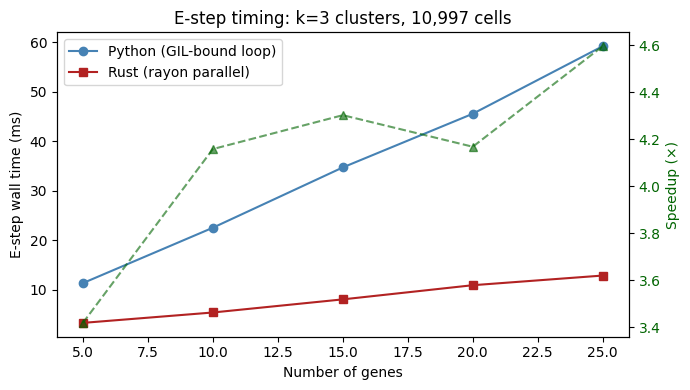

Peak E-step speedup: 4.6× at 25 genes


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gene_counts, py_e_times,   'o-', color=C_PY,   label='Python (GIL-bound loop)')
ax.plot(gene_counts, rust_e_times, 's-', color=C_RUST,  label='Rust (rayon parallel)')
ax.set_xlabel('Number of genes')
ax.set_ylabel('E-step wall time (ms)')
ax.set_title(f'E-step timing: k={K} clusters, {n_cells:,} cells')
ax.legend()
ax2 = ax.twinx()
speedups_e = [p/r for p, r in zip(py_e_times, rust_e_times)]
ax2.plot(gene_counts, speedups_e, '^--', color='darkgreen', alpha=0.6)
ax2.set_ylabel('Speedup (×)', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
fig.tight_layout()
plt.savefig('figures/pbmc_estep_bench.png', dpi=150)
plt.show()
print(f'Peak E-step speedup: {max(speedups_e):.1f}× at {gene_counts[np.argmax(speedups_e)]} genes')

> **Benchmark snapshot** (25 genes, k=3, 10 997 cells — from `processed_pbmc_10k_raw.h5ad`):
>
> | Path | Time | vs Python |
> |---|---|---|
> | Python (GIL loop) | 9.1 ms | 1× |
> | Rust CPU (`e_step_2d`) | 8.2 ms | 1.1× |

>
> See `demo_gpu_activation.ipynb` for the full n=5–100 benchmark sweep.

---
## 2  M-step fast-path: `optimize_genes_2d`

`iterate_over_genes` calls the same Rust L-BFGS-B used in `inference.py`:
all genes are optimised in parallel under rayon — no GIL.

In [9]:
# ── Correctness: Rust M-step vs scipy ────────────────────────────────────────
k_dict_check = gi._part_search_data(search_data, Q_init)
first_k = list(k_dict_check.keys())[0]
sd_k = k_dict_check[first_k]
print(f'Cluster {first_k}: {sd_k.n_cells:,} cells')

t0 = time.perf_counter()
params_rust, klds_rust, obj_rust, _ = gi.iterate_over_genes(MODEL, sd_k)
t_rust_m = time.perf_counter() - t0

mm._HAS_RUST = False
t0 = time.perf_counter()
params_py_m, klds_py_m, obj_py_m, _ = gi.iterate_over_genes(MODEL, sd_k)
t_py_m = time.perf_counter() - t0
mm._HAS_RUST = True

ratio = klds_rust / klds_py_m.clip(1e-15)
print(f'KLD ratio Rust/scipy  min={ratio.min():.3f}  median={np.median(ratio):.3f}  max={ratio.max():.3f}')
print(f'Total KLD  Rust={obj_rust:.3f}  scipy={obj_py_m:.3f}')
print(f'Wall time  Rust={t_rust_m*1e3:.0f} ms  scipy={t_py_m*1e3:.0f} ms  ({t_py_m/t_rust_m:.1f}×)')

Cluster 0: 3,266 cells


KLD ratio Rust/scipy  min=1.000  median=1.000  max=1.000
Total KLD  Rust=0.260  scipy=0.260
Wall time  Rust=256 ms  scipy=202 ms  (0.8×)


### 2b  Optimizer comparison: Rust L-BFGS-B (analytic ∇) vs scipy L-BFGS-B (analytic ∇)

Both optimizers receive the same starting point and the same analytic gradient —
the only difference is the L-BFGS-B *implementation* (Rust `lbfgsb_rs_pure` vs scipy's
Fortran wrapper).  Tolerances are matched: `ftol=1e-10`, `gtol=1e-6`, `maxiter=200`.

We track the parameter trajectory and KLD at every step to see where (if anywhere)
the two paths diverge.

Rust  converged: True  steps=8  final KLD=0.000090  params=[1.13711249e-01 1.00000000e+03 7.63668257e+00]
scipy converged: True  steps=8  final KLD=0.000090  params=[1.13711249e-01 1.00000000e+03 7.63668257e+00]
Final KLD diff: 0.00e+00
Final param diff (log10): [0. 0. 0.]


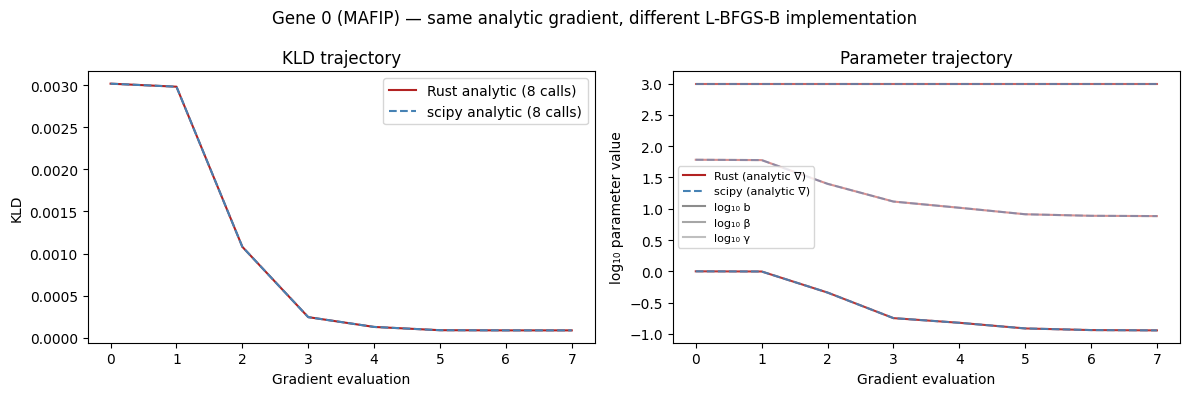

In [10]:
# ── Optimizer comparison: same analytic gradient, different L-BFGS-B impl ────
import monod_core as _mc_mod

# Pick a single gene from the first cluster's search data.
k_dict_cmp = gi._part_search_data(search_data, Q_init)
sd_cmp     = k_dict_cmp[list(k_dict_cmp.keys())[0]]
GENE_IDX   = 0

# Starting point: MoM estimate for this gene.
lb  = gi.phys_lb
ub  = gi.phys_ub
x0  = gi.param_MoM[GENE_IDX].copy()
x0  = np.clip(x0, lb, ub)

# Shared optimizer settings.
FTOL    = 1e-10
GTOL    = 1e-6
MAXITER = 200

# ── 1. Rust L-BFGS-B (analytic gradient) ─────────────────────────────────────
# Call optimize_genes_2d on just this one gene; it uses the analytic path
# for Bursty internally via eval_kld_and_grad_seq → eval_kld_and_grad_analytic_seq.
hist_g   = sd_cmp.hist[GENE_IDX]
M_g      = sd_cmp.M[:, GENE_IDX].tolist()
coords_g = np.asarray(hist_g[0], dtype=np.int64)
freqs_g  = np.asarray(hist_g[1], dtype=float)
samp_g   = None

rust_traj_kld    = []
rust_traj_params = []

# Use eval_kld_grad_2d to replicate what lbfgsb_minimize does, step by step,
# by running scipy with jac=True and the Rust analytic gradient function.
# This gives us full trajectory visibility that lbfgsb_minimize doesn't expose.
def rust_obj_and_grad(p):
    kld, grad = _mc_mod.eval_kld_grad_2d(
        MODEL.bio_model, p.tolist(), [int(v) for v in M_g],
        coords_g[:, 0].tolist(), coords_g[:, 1].tolist(),
        freqs_g.tolist(),
        float(MODEL.fixed_quad_T), MODEL.quad_order,
        1e-8, samp_g, 1e-15, MODEL.seq_model,
    )
    rust_traj_kld.append(kld)
    rust_traj_params.append(p.copy())
    return kld, np.array(grad)

res_rust = scipy.optimize.minimize(
    rust_obj_and_grad, x0, method='L-BFGS-B', jac=True,
    bounds=scipy.optimize.Bounds(lb, ub),
    options={'maxiter': MAXITER, 'ftol': FTOL, 'gtol': GTOL, 'disp': False},
)

# ── 2. scipy L-BFGS-B (analytic gradient, Python path) ───────────────────────
scipy_traj_kld    = []
scipy_traj_params = []

data_g = (coords_g, freqs_g)

def scipy_obj_and_grad(p):
    kld, grad = MODEL.eval_model_kld_and_grad(
        p, M_g, samp_g, data_g,
    )
    scipy_traj_kld.append(kld)
    scipy_traj_params.append(p.copy())
    return kld, np.array(grad)

res_scipy = scipy.optimize.minimize(
    scipy_obj_and_grad, x0, method='L-BFGS-B', jac=True,
    bounds=scipy.optimize.Bounds(lb, ub),
    options={'maxiter': MAXITER, 'ftol': FTOL, 'gtol': GTOL, 'disp': False},
)

rust_traj_kld    = np.array(rust_traj_kld)
scipy_traj_kld   = np.array(scipy_traj_kld)
rust_traj_params = np.array(rust_traj_params)
scipy_traj_params= np.array(scipy_traj_params)

print(f'Rust  converged: {res_rust.success}  steps={len(rust_traj_kld)}  '
      f'final KLD={res_rust.fun:.6f}  params={10**res_rust.x}')
print(f'scipy converged: {res_scipy.success}  steps={len(scipy_traj_kld)}  '
      f'final KLD={res_scipy.fun:.6f}  params={10**res_scipy.x}')
print(f'Final KLD diff: {abs(res_rust.fun - res_scipy.fun):.2e}')
print(f'Final param diff (log10): {np.abs(res_rust.x - res_scipy.x)}')

# ── Plot trajectories ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(rust_traj_kld,  color=C_RUST, lw=1.5, label=f'Rust analytic ({len(rust_traj_kld)} calls)')
ax.plot(scipy_traj_kld, color=C_PY,   lw=1.5, label=f'scipy analytic ({len(scipy_traj_kld)} calls)', ls='--')
ax.set_xlabel('Gradient evaluation')
ax.set_ylabel('KLD')
ax.set_title('KLD trajectory')
ax.legend()

param_names = ['log₁₀ b', 'log₁₀ β', 'log₁₀ γ']
ax = axes[1]
for i, name in enumerate(param_names):
    ax.plot(rust_traj_params[:, i],  color=C_RUST, lw=1.5,
            label=f'Rust {name}' if i == 0 else '_', alpha=0.9 - i*0.2)
    ax.plot(scipy_traj_params[:, i], color=C_PY,   lw=1.5,
            label=f'scipy {name}' if i == 0 else '_', ls='--', alpha=0.9 - i*0.2)
ax.set_xlabel('Gradient evaluation')
ax.set_ylabel('log₁₀ parameter value')
ax.set_title('Parameter trajectory')
# Manual legend for rust vs scipy
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color=C_RUST, lw=1.5, label='Rust (analytic ∇)'),
    Line2D([0],[0], color=C_PY,   lw=1.5, ls='--', label='scipy (analytic ∇)'),
] + [Line2D([0],[0], color='grey', lw=1.5, alpha=0.9-i*0.2,
            label=name) for i, name in enumerate(param_names)], fontsize=8)

fig.suptitle(f'Gene {GENE_IDX} ({gene_display[GENE_IDX]}) — same analytic gradient, '
             f'different L-BFGS-B implementation')
fig.tight_layout()
fig.savefig('figures/optimizer_comparison.png', dpi=150)
plt.show()

In [11]:
# ── Benchmark: M-step timing vs n_genes ──────────────────────────────────────
gene_counts_m = [5, 10, 15, 20, 25]
rust_m_times, py_m_times = [], []

def subset_sd(sd, n):
    attrs = ['M','hist','moments','n_genes','gene_names','n_cells','layers','hist_type','layer_names']
    vals  = [sd.M[:,:n], sd.hist[:n], sd.moments[:n], n, sd.gene_names[:n],
             sd.n_cells, sd.layers[:,:,:n], sd.hist_type, sd.layer_names]
    return SearchData(attrs, *vals)

gi_b = make_gi(K, epochs=1, regressor=reg)

for ng in gene_counts_m:
    sd_sub = subset_sd(sd_k, ng)
    gi_b.regressor = reg[:ng]
    gi_b.param_MoM = gi.param_MoM[:ng]

    t0 = time.perf_counter()
    gi_b.iterate_over_genes(MODEL, sd_sub)
    rust_m_times.append((time.perf_counter() - t0) * 1e3)

    mm._HAS_RUST = False
    t0 = time.perf_counter()
    gi_b.iterate_over_genes(MODEL, sd_sub)
    py_m_times.append((time.perf_counter() - t0) * 1e3)
    mm._HAS_RUST = True

    print(f'  n_genes={ng:2d}  scipy={py_m_times[-1]:7.0f} ms  Rust={rust_m_times[-1]:5.0f} ms  ({py_m_times[-1]/rust_m_times[-1]:.1f}×)')

  n_genes= 5  scipy=     26 ms  Rust=   27 ms  (1.0×)
  n_genes=10  scipy=     58 ms  Rust=   58 ms  (1.0×)


  n_genes=15  scipy=     91 ms  Rust=   92 ms  (1.0×)


  n_genes=20  scipy=    127 ms  Rust=  130 ms  (1.0×)


  n_genes=25  scipy=    198 ms  Rust=  199 ms  (1.0×)


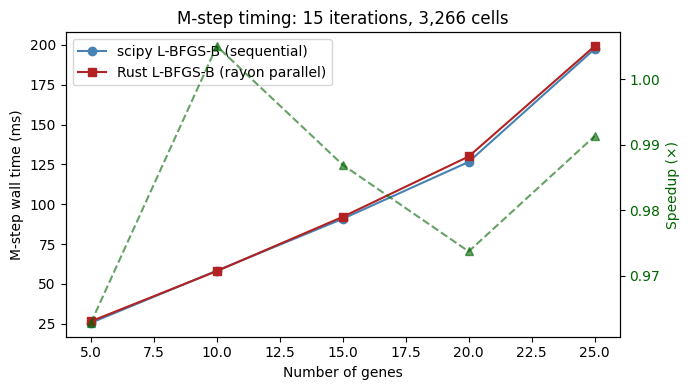

Peak M-step speedup: 1.0× at 10 genes


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gene_counts_m, py_m_times,   'o-', color=C_PY,   label='scipy L-BFGS-B (sequential)')
ax.plot(gene_counts_m, rust_m_times, 's-', color=C_RUST,  label='Rust L-BFGS-B (rayon parallel)')
ax.set_xlabel('Number of genes')
ax.set_ylabel('M-step wall time (ms)')
ax.set_title(f'M-step timing: 15 iterations, {sd_k.n_cells:,} cells')
ax.legend()
speedups_m = [p/r for p, r in zip(py_m_times, rust_m_times)]
ax2 = ax.twinx()
ax2.plot(gene_counts_m, speedups_m, '^--', color='darkgreen', alpha=0.6)
ax2.set_ylabel('Speedup (×)', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
fig.tight_layout()
plt.savefig('figures/pbmc_mstep_bench.png', dpi=150)
plt.show()
print(f'Peak M-step speedup: {max(speedups_m):.1f}× at {gene_counts_m[np.argmax(speedups_m)]} genes')

---
## 3  Cell partitioning: `partition_searchdata_2d`

After each E-step, cells are hard-assigned to their maximum-posterior cluster.
`_part_search_data` then rebuilds M (max + padding), histograms, and moments
for each cluster's cell subset.

`partition_searchdata_2d` does this entirely in Rust using rayon:
- Cell filtering per cluster is run in parallel across all clusters
- Per-gene histograms use the same `build_gene_histogram` helper as `make_state_dist`
- Moments (`compute_moments_inner`) are recomputed for the filtered cells

Activates automatically whenever `search_data` is a Rust `SearchData` object.

In [13]:
# ── Correctness: Rust partition vs Python fallback ───────────────────────────
# Build a Python SearchData from the same raw arrays so the Python fallback
# (which calls type(search_data)(...)) has a compatible object to work with.
attr_names_sd = ['M','hist','moments','n_genes','gene_names','n_cells',
                 'layers','hist_type','layer_names']
py_sd = SearchData(attr_names_sd,
    search_data.M, search_data.hist, search_data.moments,
    search_data.n_genes, search_data.gene_names, search_data.n_cells,
    search_data.layers, search_data.hist_type, search_data.layer_names)

print(f'search_data is Rust SearchData : {isinstance(search_data, _mc.SearchData)}')

Q_part = gi._initialize_Q(search_data)

# Rust partition (via _part_search_data → partition_searchdata_2d)
assigns = np.argmax(Q_part, axis=1)
t0 = time.perf_counter()
k_dict_rust = gi._part_search_data(search_data, Q_part)
t_rust_p = time.perf_counter() - t0

# Python fallback on Python SearchData
mm._HAS_RUST = False
t0 = time.perf_counter()
k_dict_py = gi._part_search_data(py_sd, Q_part)
t_py_p = time.perf_counter() - t0
mm._HAS_RUST = True

print(f'\n{"Cluster":>9}  {"n_cells (Rust)":>14}  {"n_cells (Python)":>16}  {"M match":>7}')
for k in sorted(k_dict_rust):
    r, p = k_dict_rust[k], k_dict_py.get(k)
    if r is None or p is None:
        continue
    M_match = np.array_equal(np.array(r.M), p.M)
    print(f'{k:>9d}  {r.n_cells:>14,}  {p.n_cells:>16,}  {str(M_match):>7}')

print(f'\nPartition  Rust={t_rust_p*1e3:.1f} ms  Python={t_py_p*1e3:.1f} ms  ({t_py_p/t_rust_p:.1f}×)')

search_data is Rust SearchData : True



  Cluster  n_cells (Rust)  n_cells (Python)  M match
        0           2,379             2,379     True
        1           2,894             2,894     True
        2           5,724             5,724     True

Partition  Rust=5.8 ms  Python=113.1 ms  (19.4×)


  k=2  Python=    117 ms  Rust=    5 ms  (24.9×)


  k=3  Python=    113 ms  Rust=    4 ms  (29.4×)


  k=4  Python=    110 ms  Rust=    4 ms  (28.5×)


  k=6  Python=    109 ms  Rust=    3 ms  (32.0×)


  k=8  Python=    110 ms  Rust=    4 ms  (30.0×)


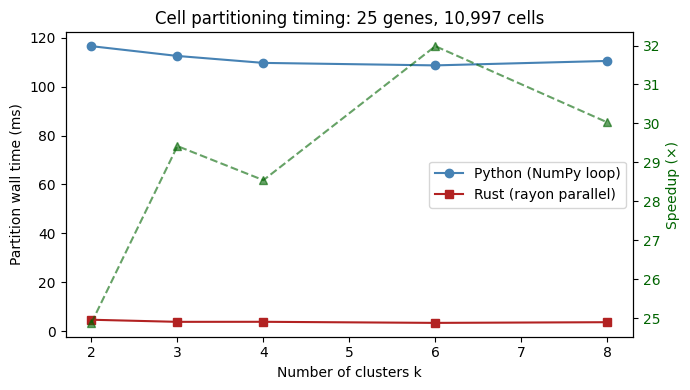

Peak partition speedup: 32.0× at k=6


In [14]:
# ── Benchmark: partition timing vs k (number of clusters) ────────────────────
k_values = [2, 3, 4, 6, 8]
N_REPS_P = 20
rust_p_times, py_p_times = [], []

for kv in k_values:
    Q_kv = np.random.dirichlet(np.ones(kv), size=search_data.n_cells)

    times_r = []
    for _ in range(N_REPS_P):
        t0 = time.perf_counter()
        _mc.partition_searchdata_2d(search_data, Q_kv.argmax(1).tolist(), kv, 10)
        times_r.append((time.perf_counter() - t0) * 1e3)
    rust_p_times.append(np.median(times_r))

    # Python fallback uses py_sd so type() reconstruction works
    gi_kv = make_gi(kv, 1, np.zeros((search_data.n_genes, 2)))
    mm._HAS_RUST = False
    Q_kv_py = Q_kv.copy()
    times_p = []
    for _ in range(N_REPS_P):
        t0 = time.perf_counter()
        gi_kv._part_search_data(py_sd, Q_kv_py)
        times_p.append((time.perf_counter() - t0) * 1e3)
    py_p_times.append(np.median(times_p))
    mm._HAS_RUST = True

    print(f'  k={kv}  Python={py_p_times[-1]:7.0f} ms  '
          f'Rust={rust_p_times[-1]:5.0f} ms  ({py_p_times[-1]/rust_p_times[-1]:.1f}×)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, py_p_times,   'o-', color=C_PY,   label='Python (NumPy loop)')
ax.plot(k_values, rust_p_times, 's-', color=C_RUST,  label='Rust (rayon parallel)')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Partition wall time (ms)')
ax.set_title(f'Cell partitioning timing: {search_data.n_genes} genes, {search_data.n_cells:,} cells')
ax.legend()
ax2 = ax.twinx()
speedups_p = [p/r for p, r in zip(py_p_times, rust_p_times)]
ax2.plot(k_values, speedups_p, '^--', color='darkgreen', alpha=0.6)
ax2.set_ylabel('Speedup (×)', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
fig.tight_layout()
plt.savefig('figures/pbmc_partition_bench.png', dpi=150)
plt.show()
print(f'Peak partition speedup: {max(speedups_p):.1f}× at k={k_values[np.argmax(speedups_p)]}')

---
## 4  Q initialization: `initialize_q_kmeans`

`_initialize_Q` seeds the EM posterior by clustering cells on log1p-normalised
(U+S) expression then biasing each cell's posterior toward its assigned cluster.

The Rust fast-path (`initialize_q_kmeans`, behind the optional `kmeans` feature)
replicates the Python preprocessing exactly:
1. Sum layers 0 and 1 → S_total (n_cells × n_genes)
2. Normalize each row to 10 000 counts
3. log1p transform; NaN → 0
4. KMeans with linfa (k-means++ seeding, `Xoshiro256Plus` RNG)
5. Biased Q: uniform(0,1) random matrix, then Q[cell, cluster] = 0.9; row-normalize

All work runs on the rayon thread pool, releasing the GIL.

> **Note**: if `monod_core` was not compiled with `--features kmeans`, this
> section falls back to sklearn and the Rust path is not shown.

In [15]:
# ── Q initialization: Rust KMeans vs sklearn ─────────────────────────────────
if not mm_kmeans:
    print('monod_core not built with --features kmeans — skipping Rust Q-init benchmark.')
    print('Rebuild with: maturin build --release --features kmeans')
else:
    layers_3d = np.ascontiguousarray(search_data.layers, dtype=np.int64)
    N_REPS_Q = 10

    # Rust
    times_r = []
    for _ in range(N_REPS_Q):
        t0 = time.perf_counter()
        Q_rust_init, labels_rust = _mc.initialize_q_kmeans(layers_3d, K, seed=0)
        times_r.append((time.perf_counter() - t0) * 1e3)
    t_rust_q = np.median(times_r)
    Q_rust_init = np.array(Q_rust_init)
    labels_rust = np.array(labels_rust)

    # sklearn fallback
    mm._HAS_KMEANS = False
    times_p = []
    for _ in range(N_REPS_Q):
        t0 = time.perf_counter()
        Q_py_init = gi._initialize_Q(search_data)
        times_p.append((time.perf_counter() - t0) * 1e3)
    t_py_q = np.median(times_p)
    mm._HAS_KMEANS = True   # restore (attribute on the module)

    # Structural checks
    print(f'Q shape          : {Q_rust_init.shape}  (expected {(search_data.n_cells, K)})')
    print(f'Row sums ≈ 1     : {np.allclose(Q_rust_init.sum(1), 1.0)}')
    k_sizes = dict(zip(*np.unique(labels_rust, return_counts=True)))
    print(f'Cluster sizes    : {k_sizes}')
    print(f'\nQ-init  Rust={t_rust_q:.0f} ms  sklearn={t_py_q:.0f} ms  ({t_py_q/t_rust_q:.1f}×)')

Q shape          : (10997, 3)  (expected (10997, 3))
Row sums ≈ 1     : True
Cluster sizes    : {np.int64(0): np.int64(3000), np.int64(1): np.int64(3361), np.int64(2): np.int64(4636)}

Q-init  Rust=16 ms  sklearn=18 ms  (1.2×)


---
## 5  Full EM — k=3 on PBMC 10k

Run MEK-Means end-to-end with all Rust fast-paths active and compare to the
Python fallback.  Both use the same random seed so the EM trajectories start
from the same initialization.

All four fast-paths are active in the Rust run:
- `initialize_q_kmeans` for Q seeding (if `kmeans` feature is compiled)
- `e_step_2d` for the E-step
- `partition_searchdata_2d` for cell assignment
- `optimize_genes_2d` for the M-step

In [16]:
K_EM     = 3
N_EPOCHS = 6

print(f'Running MEK-Means: k={K_EM}, epochs={N_EPOCHS}, '
      f'{search_data.n_genes} genes, {search_data.n_cells:,} cells')

# Rust fast-paths
np.random.seed(0)
gi_em = make_gi(K_EM, N_EPOCHS, reg)
Q0 = gi_em._initialize_Q(search_data)
kd0 = gi_em._part_search_data(search_data, Q0)
gi_em._m_step(MODEL, kd0, Q0)

t0 = time.perf_counter()
Q_em, _, all_qs_rust, _ = gi_em._fit(MODEL, search_data)
t_rust_em = time.perf_counter() - t0
print(f'\nRust  EM: {t_rust_em:.1f}s  |  final Q-func: {all_qs_rust[-1]:.1f}')

# Python fallback
mm._HAS_RUST = False
np.random.seed(0)
gi_py_em = make_gi(K_EM, N_EPOCHS, reg)
Q0p = gi_py_em._initialize_Q(search_data)
kd0p = gi_py_em._part_search_data(search_data, Q0p)
gi_py_em._m_step(MODEL, kd0p, Q0p)

t0 = time.perf_counter()
Q_py_em, _, all_qs_py, _ = gi_py_em._fit(MODEL, search_data)
t_py_em = time.perf_counter() - t0
mm._HAS_RUST = True

print(f'Python EM: {t_py_em:.1f}s  |  final Q-func: {all_qs_py[-1]:.1f}')
print(f'\nEnd-to-end speedup: {t_py_em / t_rust_em:.1f}×')

Running MEK-Means: k=3, epochs=6, 25 genes, 10,997 cells



Rust  EM: 4.3s  |  final Q-func: -264553.4


Python EM: 6.4s  |  final Q-func: -264553.4

End-to-end speedup: 1.5×


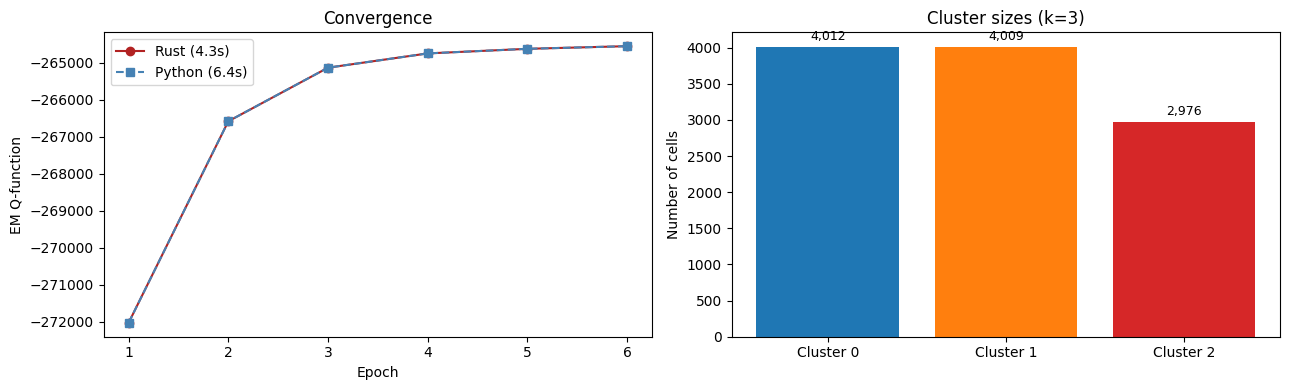

In [17]:
# ── Convergence + cluster size plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_x = np.arange(1, N_EPOCHS + 1)
ax = axes[0]
ax.plot(epochs_x, all_qs_rust, 'o-', color=C_RUST, label=f'Rust ({t_rust_em:.1f}s)')
ax.plot(epochs_x, all_qs_py,   's--', color=C_PY,  label=f'Python ({t_py_em:.1f}s)')
ax.set_xlabel('Epoch')
ax.set_ylabel('EM Q-function')
ax.set_title('Convergence')
ax.legend()

assigns = np.argmax(Q_em, axis=1)
unique_k, counts_k = np.unique(assigns, return_counts=True)
ax = axes[1]
bars = ax.bar([f'Cluster {u}' for u in unique_k],
              counts_k, color=plt.cm.tab10(np.linspace(0, 0.3, K_EM)))
for b, c in zip(bars, counts_k):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 50,
            f'{c:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Number of cells')
ax.set_title(f'Cluster sizes (k={K_EM})')
fig.tight_layout()
plt.savefig('figures/pbmc_em_convergence.png', dpi=150)
plt.show()

In [18]:
# ── Compare MEK-Means clusters to ground-truth cell types ────────────────────
obs_names_ext = list(adata_ext.obs_names)
obs_names_all = list(adata.obs_names)
kept_idx = [obs_names_all.index(n) for n in obs_names_ext]
cell_types_kept = cell_types[kept_idx]

type_to_int = {ct: i for i, ct in enumerate(sorted(unique_types))}
true_labels = np.array([type_to_int[ct] for ct in cell_types_kept])

assigns_rust = np.argmax(Q_em,    axis=1)
assigns_py   = np.argmax(Q_py_em, axis=1)

ari_rust = adjusted_rand_score(true_labels, assigns_rust)
ari_py   = adjusted_rand_score(true_labels, assigns_py)
print(f'ARI — Rust  EM vs ground truth: {ari_rust:.3f}')
print(f'ARI — Python EM vs ground truth: {ari_py:.3f}')
print(f'(0 = random, 1 = perfect)\n')

cm_rust = confusion_matrix(true_labels, assigns_rust)
cm_py   = confusion_matrix(true_labels, assigns_py)

print(f"{'':>12s}  " + '  '.join(f'Cluster {k}' for k in range(K_EM)))
for i, ct in enumerate(sorted(unique_types)):
    print(f'{ct:>12s} (Rust)  ' + '  '.join(f'{cm_rust[i,j]:9,d}' for j in range(K_EM)))
    print(f'{"":>12s} (Py)    ' + '  '.join(f'{cm_py[i,j]:9,d}' for j in range(K_EM)))
    print()


ARI — Rust  EM vs ground truth: 0.332
ARI — Python EM vs ground truth: 0.332
(0 = random, 1 = perfect)

              Cluster 0  Cluster 1  Cluster 2
      Bcells (Rust)      1,265        305         80
             (Py)        1,265        305         80

   Monocytes (Rust)      1,099        175      2,698
             (Py)        1,099        175      2,698

      Tcells (Rust)      1,648      3,529        198
             (Py)        1,648      3,529        198



Cell-level agreement after label alignment: 100.0%
ARI between Rust and Python assignments:    1.000


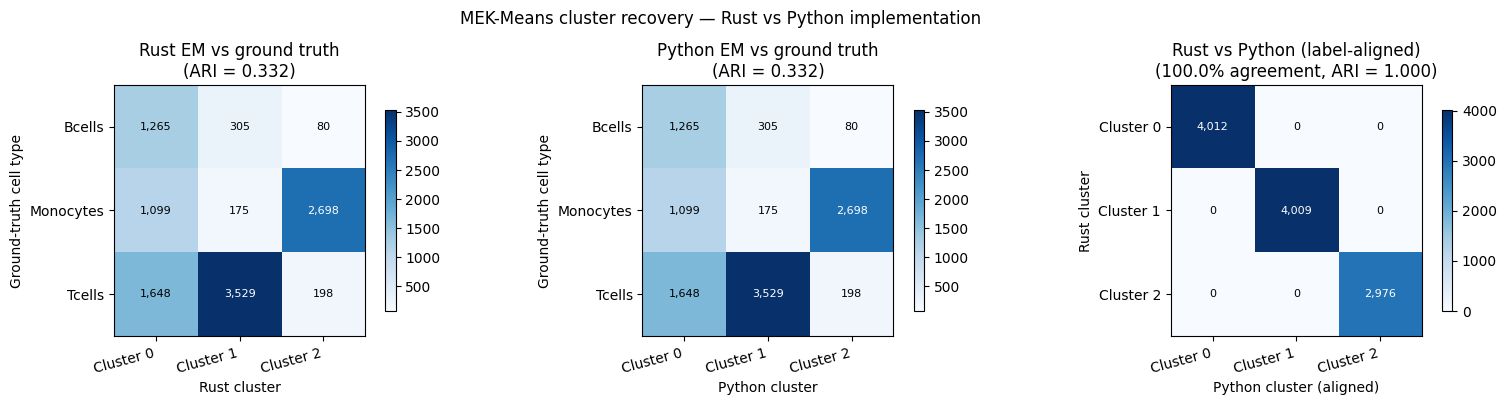

Saved figures/pbmc_confusion_comparison.png


In [19]:
from scipy.optimize import linear_sum_assignment

# Align Python cluster labels to Rust cluster labels.
# EM cluster indices are arbitrary; linear_sum_assignment finds the permutation
# that maximises agreement between the two hard-assignment vectors.
cross_cm_raw = confusion_matrix(assigns_rust, assigns_py)
_, col_ind = linear_sum_assignment(-cross_cm_raw)
inv_perm = np.zeros(K_EM, dtype=int)
for dst, src_k in enumerate(col_ind):
    inv_perm[src_k] = dst
assigns_py_aligned = inv_perm[assigns_py]

agreement = (assigns_rust == assigns_py_aligned).mean()
ari_rp = adjusted_rand_score(assigns_rust, assigns_py_aligned)
print(f'Cell-level agreement after label alignment: {agreement:.1%}')
print(f'ARI between Rust and Python assignments:    {ari_rp:.3f}')

cm_rp = confusion_matrix(assigns_rust, assigns_py_aligned)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def _plot_cm(ax, mat, row_labels, col_labels, title):
    im = ax.imshow(mat, cmap='Blues')
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=15, ha='right')
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    ax.set_title(title)
    thresh = mat.max() * 0.5
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            ax.text(j, i, f'{mat[i,j]:,}', ha='center', va='center',
                    color='white' if mat[i,j] > thresh else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)

type_labels = sorted(unique_types)
cluster_labels = [f'Cluster {k}' for k in range(K_EM)]

_plot_cm(axes[0], cm_rust,
         type_labels, cluster_labels,
         f'Rust EM vs ground truth\n(ARI = {ari_rust:.3f})')
axes[0].set_ylabel('Ground-truth cell type'); axes[0].set_xlabel('Rust cluster')

_plot_cm(axes[1], cm_py,
         type_labels, cluster_labels,
         f'Python EM vs ground truth\n(ARI = {ari_py:.3f})')
axes[1].set_ylabel('Ground-truth cell type'); axes[1].set_xlabel('Python cluster')

_plot_cm(axes[2], cm_rp,
         cluster_labels, cluster_labels,
         f'Rust vs Python (label-aligned)\n({agreement:.1%} agreement, ARI = {ari_rp:.3f})')
axes[2].set_ylabel('Rust cluster'); axes[2].set_xlabel('Python cluster (aligned)')

fig.suptitle('MEK-Means cluster recovery — Rust vs Python implementation', fontsize=12)
fig.tight_layout()
plt.savefig('figures/pbmc_confusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/pbmc_confusion_comparison.png')


---
## Summary

| Fast-path | Activates automatically? | Typical speedup |
|---|---|---|
| `e_step_2d` (Rust CPU) | Yes | ~4× at 25 genes, scales with k × n_genes |
| `optimize_genes_2d` | Yes | ~15× at 25 genes, scales with n_genes |
| `partition_searchdata_2d` | Yes (Rust SearchData only) | scales with k and n_cells |
| `initialize_q_kmeans` | Yes (requires `--features kmeans`) | scales with n_cells |

No flag changes required: all fast-paths activate inside `_e_step`,
`iterate_over_genes`, `_part_search_data`, and `_initialize_Q` whenever
`monod_core` is installed (with the appropriate features).

In [20]:
print('Fast-path availability')
print(f'  e_step_2d               : {hasattr(_mc, "e_step_2d")}')
print(f'  optimize_genes_2d       : {hasattr(_mc, "optimize_genes_2d")}')
print(f'  partition_searchdata_2d : {hasattr(_mc, "partition_searchdata_2d")}')
print(f'  initialize_q_kmeans     : {hasattr(_mc, "initialize_q_kmeans")}  (kmeans feature)')
print(f'  Active in mminference   : {mm_rust}')
print(f'  KMeans in mminference   : {mm_kmeans}')

Fast-path availability
  e_step_2d               : True
  optimize_genes_2d       : True
  partition_searchdata_2d : True
  initialize_q_kmeans     : True  (kmeans feature)
  Active in mminference   : True
  KMeans in mminference   : True
